### 用到 九江 PCA101A 上试试效果

In [1]:
import torch
import argparse
import pandas as pd
import matplotlib.pyplot as plt

from models import timer_xl

In [2]:
# init the args of pre-trained Timer-XL

args = argparse.Namespace()
args.input_token_len = 96
args.output_token_len = 96
args.d_model = 1024
args.n_heads = 8
args.e_layers = 8
args.d_ff = 2048
args.dropout = 0.1
args.activation = 'relu'
args.use_norm = True
args.flash_attention = False
args.covariate = False
args.output_attention = False

model = timer_xl.Model(args)

# download the checkpoint from https://cloud.tsinghua.edu.cn/f/01c35ca13f474176be7b/
model.load_state_dict(torch.load('checkpoint.pth')) 

/home/aicode/miniconda3/envs/tsfm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<All keys matched successfully>

In [68]:
# evaluate zere-shot prediction

df = pd.read_csv("")

lookback_length = 1440      # support the maximum context length up to 2880 
input = torch.tensor(df["OT"][:lookback_length]).unsqueeze(0).float()

# generate forecast 
prediction_length = 96     # forecast the next 96 timestamps, supporting maximum prediction length encompassed in the context length

output =  model(input.unsqueeze(-1), None, None)

FileNotFoundError: [Errno 2] No such file or directory: ''

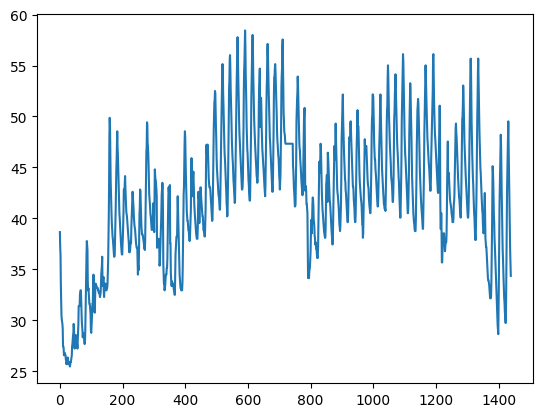

In [67]:
plt.plot(input.squeeze().detach().numpy())

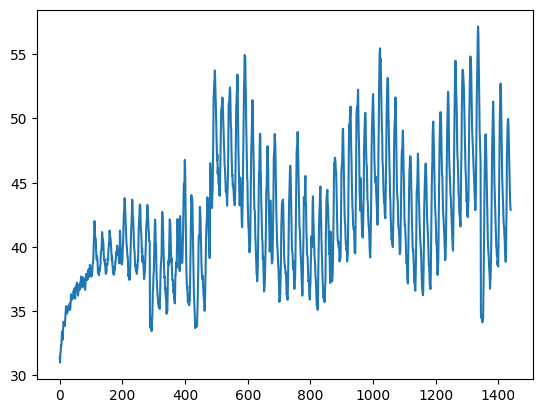

In [61]:
plt.plot(output.squeeze().detach().numpy())

In [62]:
# Note that the output is the whole sequence of next token prediction
# so we need to select the last token (token_len=96) as the final prediction

pred = output[:, -prediction_length:, 0].squeeze().detach().numpy()

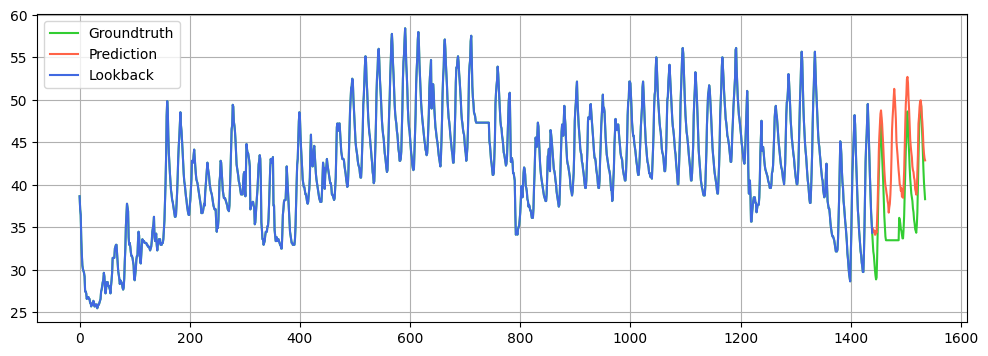

In [63]:
# plot the prediction

plt.figure(figsize=(12, 4))
plt.plot(df["OT"][:lookback_length + prediction_length], color="limegreen", label="Groundtruth")
plt.plot(range(lookback_length, lookback_length + prediction_length), pred, color="tomato", label="Prediction")
plt.plot(df["OT"][:lookback_length], color="royalblue", label="Lookback")
plt.legend()
plt.grid()
plt.show()